In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [74]:
# Reading and assigning the data to a variable

life_gdp = pd.read_csv('all_data.csv')

# viewing the dataset

life_gdp.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [4]:
life_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


In [9]:
# exploring unique countries in the dataset
life_gdp['Country'].unique()

array(['Chile', 'China', 'Germany', 'Mexico', 'United States of America',
       'Zimbabwe'], dtype=object)

In [11]:
life_gdp.Year.unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015])

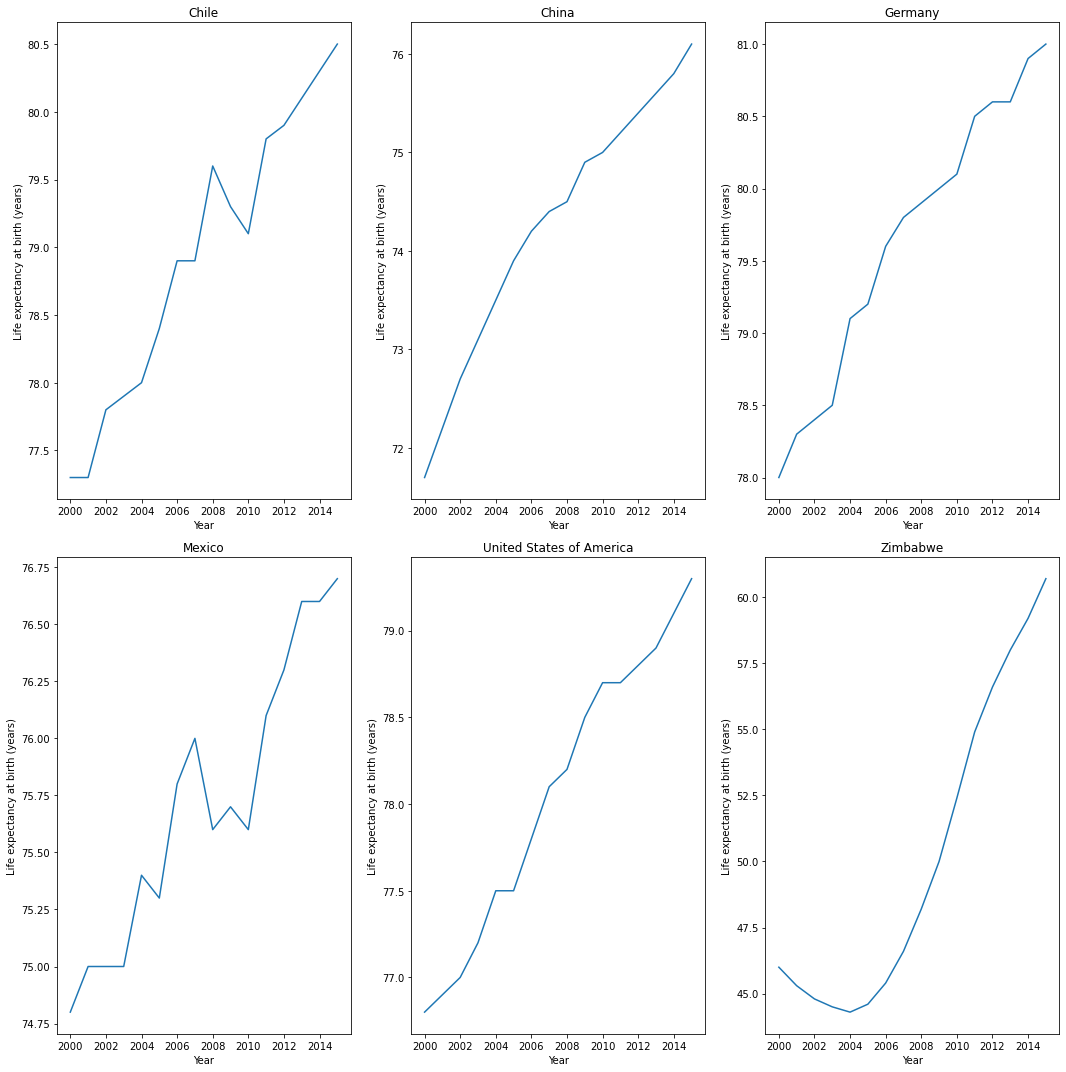

In [66]:
# Has Life Expectancy increased over time in the countries

countries = life_gdp["Country"].unique()

fig, axes = plt.subplots(2, 3, figsize =(15, 15))

for ax, country in zip(axes.flat, countries):
    data = life_gdp[life_gdp['Country'] == country]
    sns.lineplot(
    x = 'Year',
    y = 'Life expectancy at birth (years)',
    data = data,
    ax = ax)
    ax.set_title(country)
    
plt.tight_layout()
plt.show()

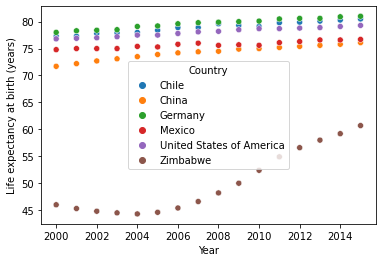

In [69]:
sns.scatterplot(x = 'Year',
    y = 'Life expectancy at birth (years)', hue = 'Country', data = life_gdp)
plt.show()

There has been a significant increase in Life expectancy in Zimbabwe as compared to the other nations which have seen slight increases. However, Zimbabwe still has the lowest Life Expectancy among the selected nations

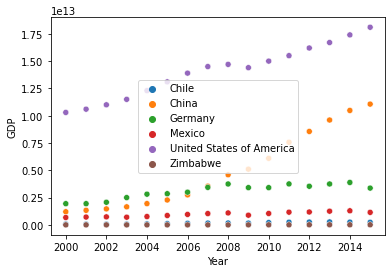

In [34]:
# Has GDP increased over time in the six nations?

sns.scatterplot(x='Year', y='GDP', hue='Country', data = life_gdp)
plt.legend(loc=0)
plt.show()

There has been a significant increase in the GDP of United States of America(USA) and China with the USA beating China by over 75%.
Germany has seen very slow and insignificant growth.
Chile, Mexico, and Zimbabwe have not had any growth within the evaluated time period. 

In [71]:
# Is there a correlation between GDP and life expectancy of a country?

corr = life_gdp['GDP'].corr(life_gdp['Life expectancy at birth (years)'])

print(f"The correlation between GDP and Life Expectancy is " + str(corr))

The correlation between GDP and Life Expectancy is 0.34320674844915594


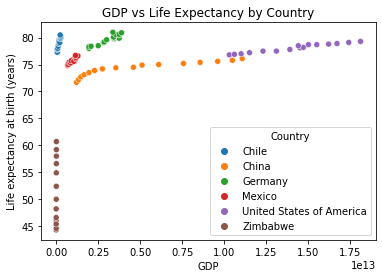

In [48]:
# checking for correlation between GDP and Life Expectancy using scatter plot

sns.scatterplot(y ='Life expectancy at birth (years)', x='GDP', hue = 'Country', data = life_gdp)
plt.title("GDP vs Life Expectancy by Country")
plt.show()

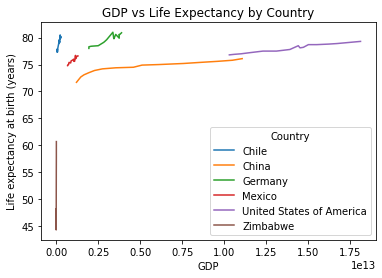

In [46]:
sns.lineplot(x = life_gdp["GDP"], y = life_gdp["Life expectancy at birth (years)"], hue = 'Country', data = life_gdp)
plt.title("GDP vs Life Expectancy by Country")
plt.show()

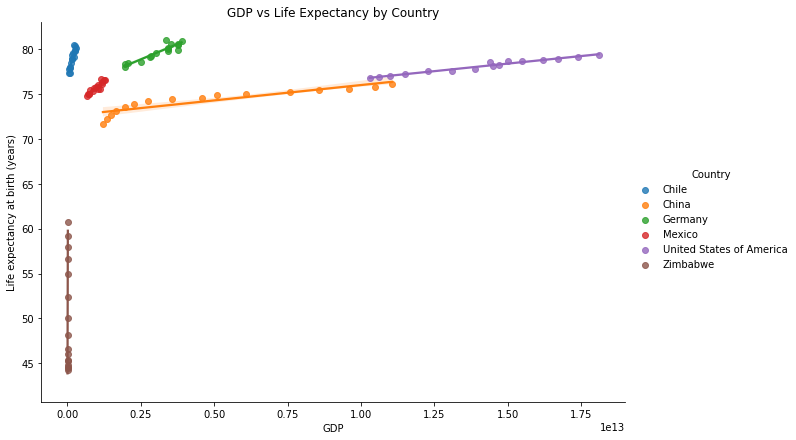

In [45]:
sns.lmplot(
    x="GDP",
    y="Life expectancy at birth (years)",
    hue="Country",
    data=life_gdp,
    height=6,
    aspect=1.5
)

plt.title("GDP vs Life Expectancy by Country")
plt.show()

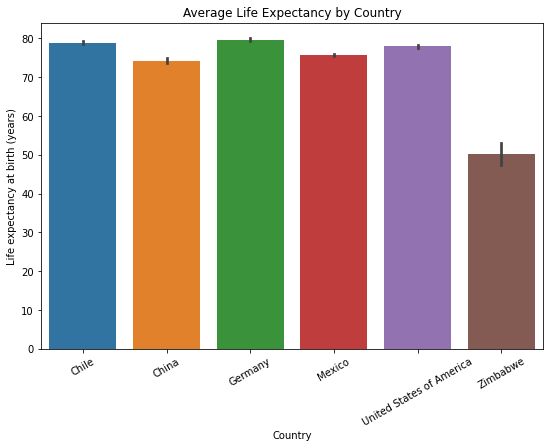

In [53]:
# What is the average life expectancy in these nations?
plt.figure(figsize = (9, 6))
sns.barplot(y="Life expectancy at birth (years)", x = 'Country', data = life_gdp)
plt.title("Average Life Expectancy by Country")
plt.xticks(rotation = 30)
plt.show()

In [54]:
# Of all the six nations, Zimbabwe has the lowest average life expectancy. 

In [106]:
life_avg = life_gdp.groupby(['Country']).agg({
    'Life expectancy at birth (years)' : 'mean',
    'GDP' : ['min', 'max']
})
life_avg.columns = ['Avg_Life_Expectancy', 'minimum_GDP_billions', 'maximum_GDP_billions']

life_avg.reset_index()

life_avg["minimum_GDP_billions"] = (life_avg["minimum_GDP_billions"] / 1e9).round(2)
life_avg["maximum_GDP_billions"] = (life_avg["maximum_GDP_billions"] / 1e9).round(2)
life_avg

,Avg_Life_Expectancy,minimum_GDP_billions,maximum_GDP_billions
Country,,,
Chile,78.94375,69.74,278.38
China,74.26250,1211.35,11064.70
Germany,79.65625,1949.95,3890.61
Mexico,75.71875,683.65,1298.46
United States of America,78.06250,10300.00,18100.00
Zimbabwe,50.09375,4.42,16.30


In [113]:
life_pivot = pd.pivot_table(life_avg, 
            
              values = ['Avg_Life_Expectancy', 'minimum_GDP_billions', 'maximum_GDP_billions'],
              columns = 'Country')
life_pivot

Country,Chile,China,Germany,Mexico,United States of America,Zimbabwe
Avg_Life_Expectancy,78.94375,74.2625,79.65625,75.71875,78.0625,50.09375
maximum_GDP_billions,278.38000,11064.7000,3890.61000,1298.46000,18100.0000,16.30000
minimum_GDP_billions,69.74000,1211.3500,1949.95000,683.65000,10300.0000,4.42000
